In [1]:
from numpy import pi
import pint
from simulation import SimulationConfig, OpticalForceCalculator, DipoleCalculator, SweepRunner
import numpy as np
ureg = pint.UnitRegistry()
import matplotlib.pyplot as plt


/home/uspensky/PyProjects/Mie_SPP_Force/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [ ]:
baseConfig = SimulationConfig(
    wl=640 * ureg.nanometer,
    R=40 * ureg.nanometer,
    dist=1 * ureg.nanometer,
    angle=np.deg2rad(25),
    psi=pi/2,
    chi=pi/4,
    substrate='Air',
    particle='SiO2',
    amplitude=1,
    show_warnings=False,
    initial_field_type='custom',
    z_beam=10 * ureg.nanometer,
    w0=450*ureg.nanometer
)

# dips = OpticalForceCalculator(baseConfig).compute()

# R_arr = np.linspace(10, 170, 50) * ureg.nanometer
# dist_arr = np.linspace(10, 170, 20) * ureg.nanometer
z_beam_arr = np.linspace(-1200, 1200, 100) * ureg.nanometer

res, _, _ = SweepRunner(baseConfig, 'z_beam', z_beam_arr, compute_force=True).run()

Custom field parameters set: w0=450 nanometer, z_beam=10 nanometer
























































































































































































































































































































































































































































































































































































































































































100%|██████████| 80/80 [00:21<00:00,  3.75it/s]


  0%|          | 0/80 [00:35<?, ?it/s]


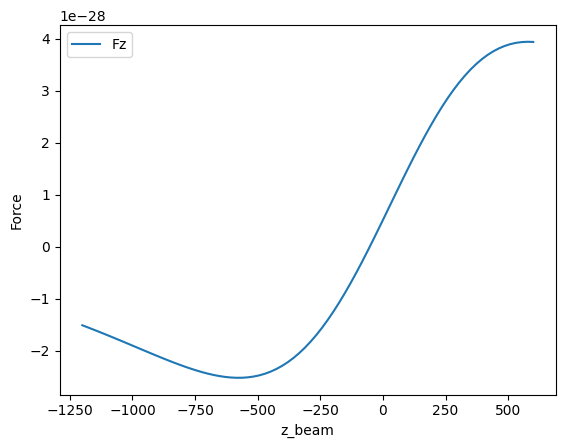

In [ ]:
# plt.plot(res.dist, res.Fx, label='Fx')
# plt.plot(res.dist, res.Fy, label='Fy')
plt.plot(res.z_beam[::-1], res.Fz, label='Fz')
plt.xlabel('z_beam')
plt.ylabel('Force')
plt.legend()
plt.show()